## Predicting house price

### Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [4]:
type(housing)

sklearn.utils._bunch.Bunch

In [5]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [6]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [8]:
print(housing.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [9]:
print(housing.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


### Prepare the data

In [10]:
dataset = pd.DataFrame(data=housing.data, columns=housing.feature_names)

In [11]:
type(dataset)

pandas.core.frame.DataFrame

In [12]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [13]:
dataset.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24


In [14]:
dataset["Price"] = housing.target


In [15]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Statistical description of the data

In [17]:
dataset.describe() 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [18]:
# check the null values in the dataset
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

### Exploratory Data Analysis

In [19]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [20]:
# removing the features as they are show high coreation with the "AveRooms" and also "Longitude"
dataset = dataset.drop(columns=["AveBedrms", "Longitude"])

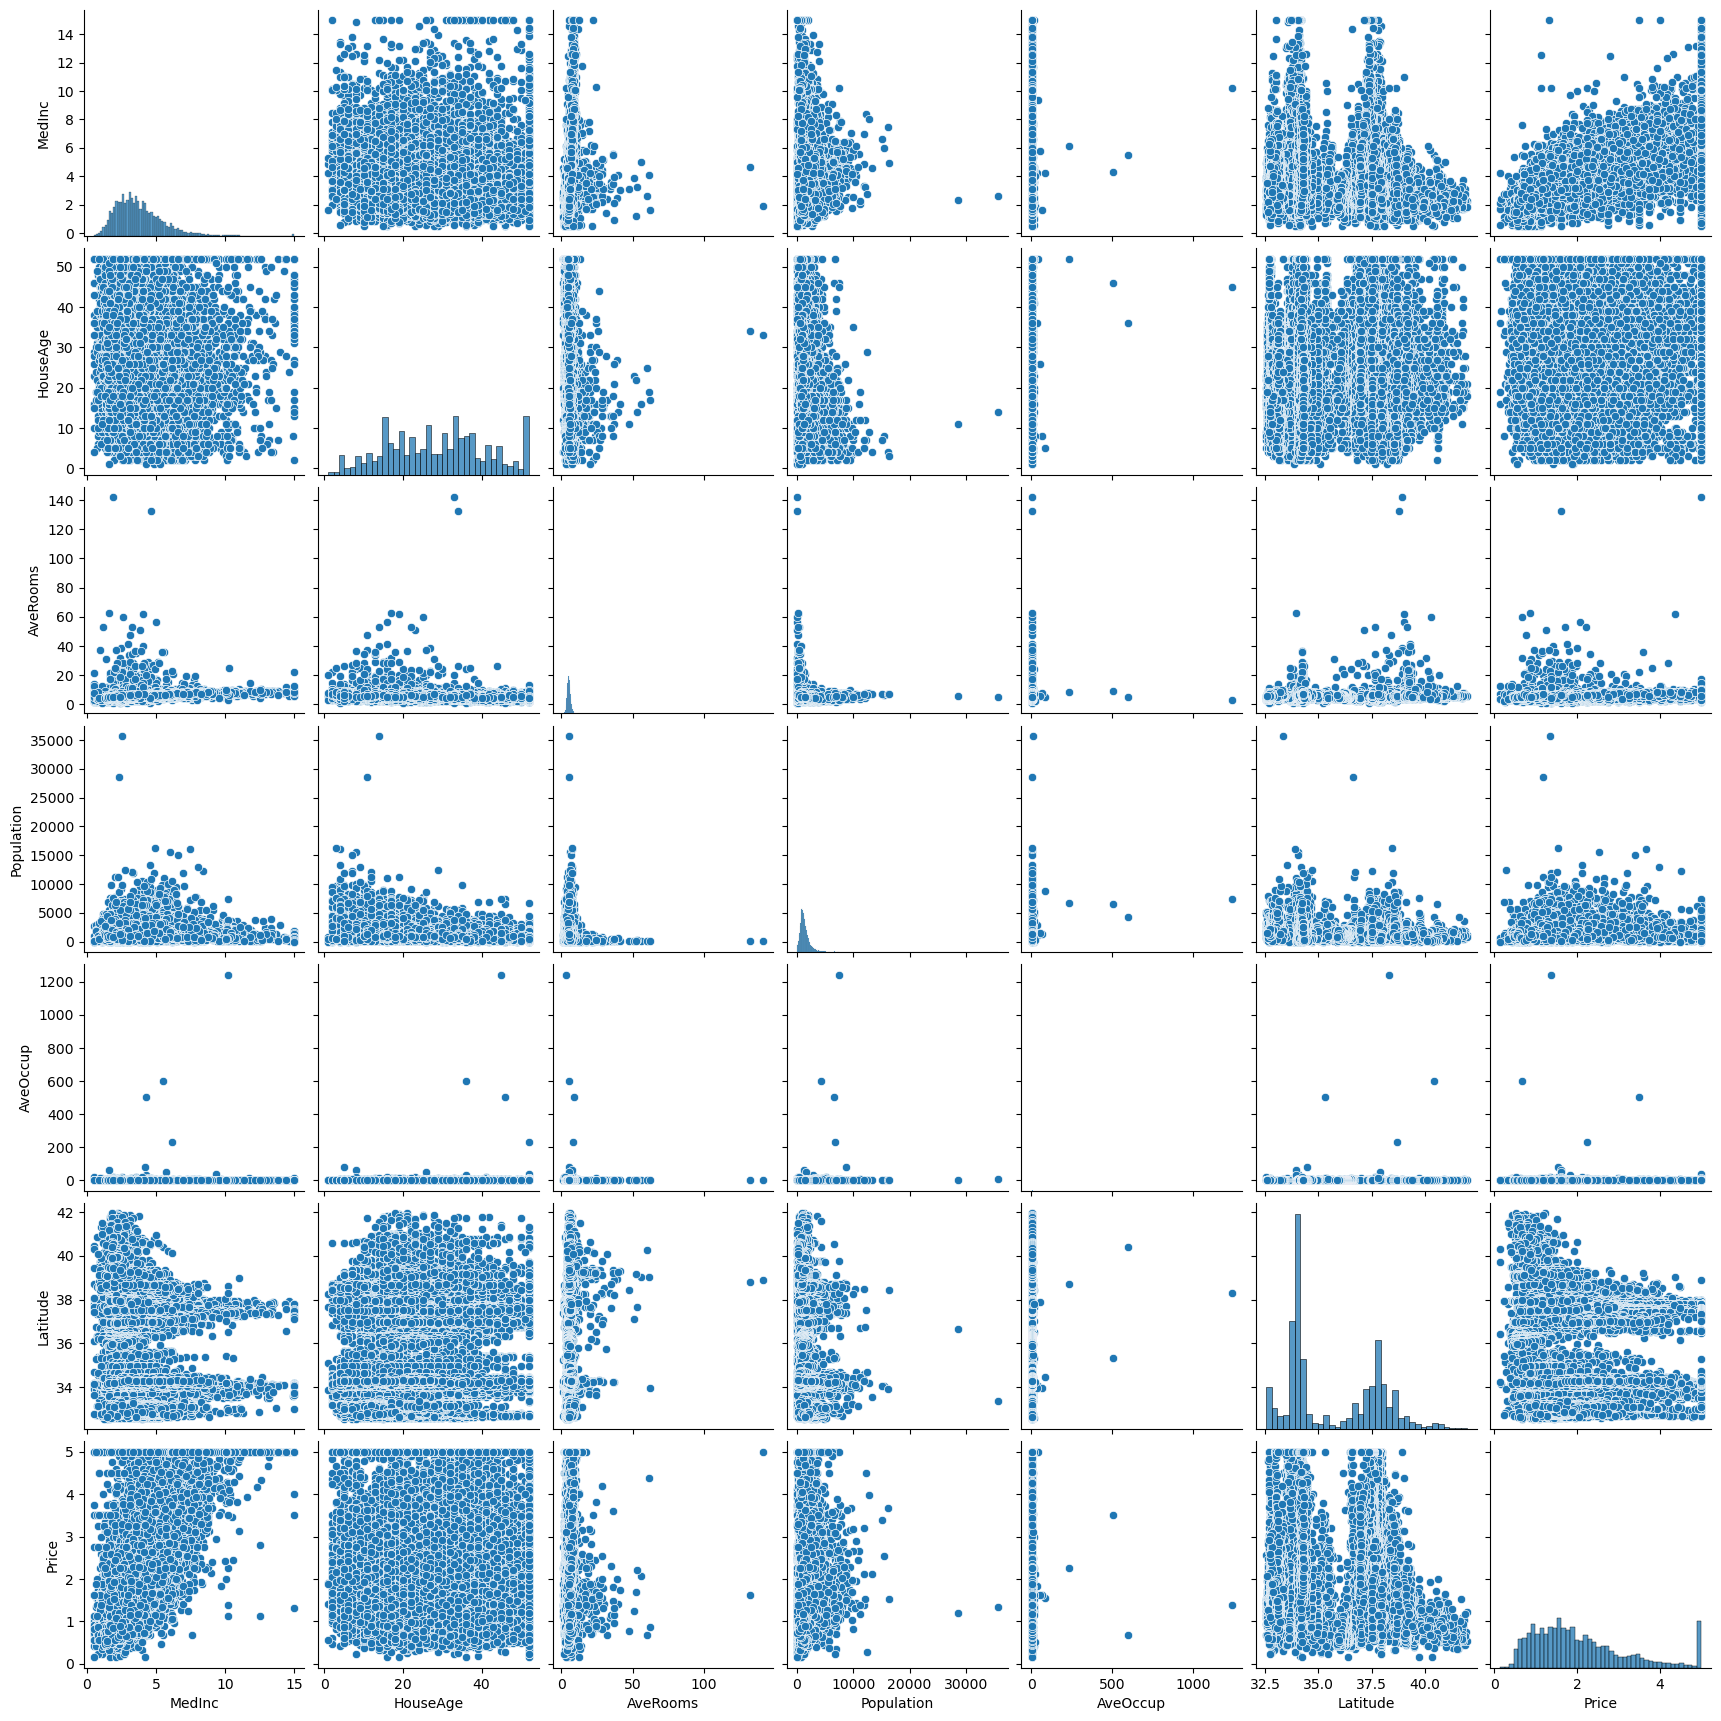

In [21]:
sns.pairplot(dataset)

<Axes: >

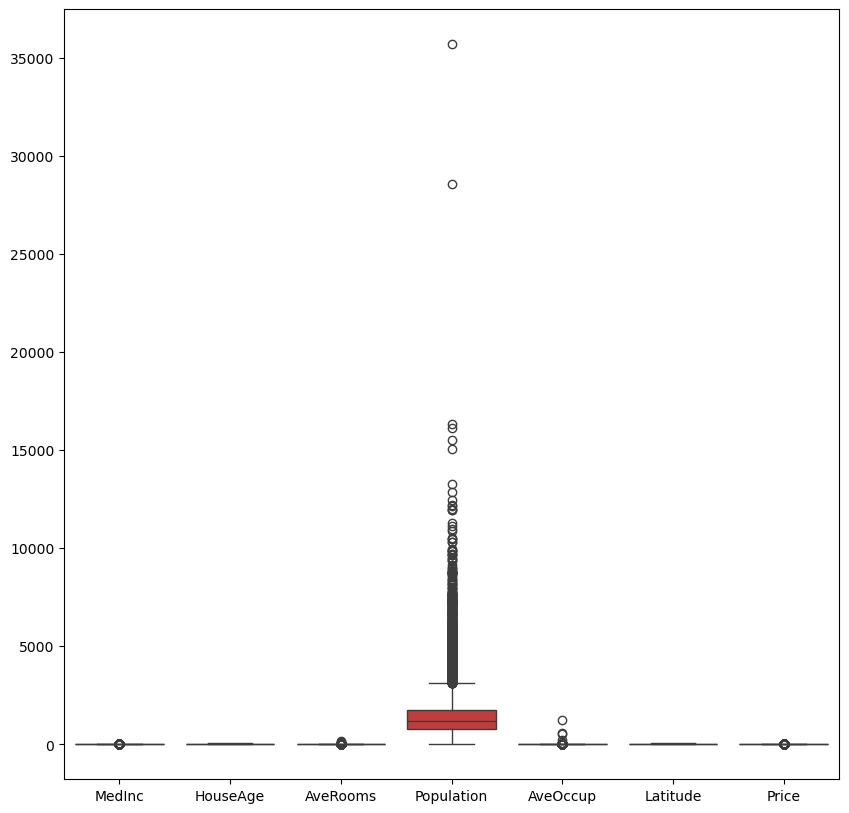

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.boxplot(data=dataset, ax=ax)
# plt.savefig("boxplot.png")

In [23]:
# Split the data into independent and dependent features
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [24]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [25]:
# normalization of the given data points
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)

In [26]:
X_train_norm.shape

(14448, 6)

<Axes: >

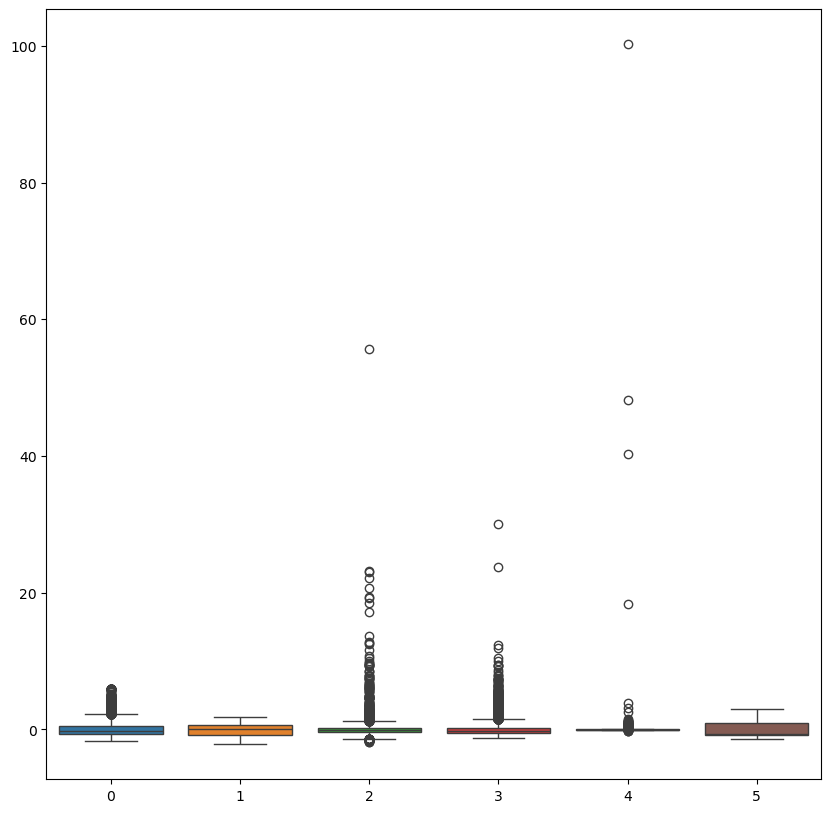

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.boxplot(data=X_train_norm, ax=ax)
# plt.savefig("boxplotTraindata.png")

In [28]:
X_test_norm = scaler.transform(X_test)

<Axes: >

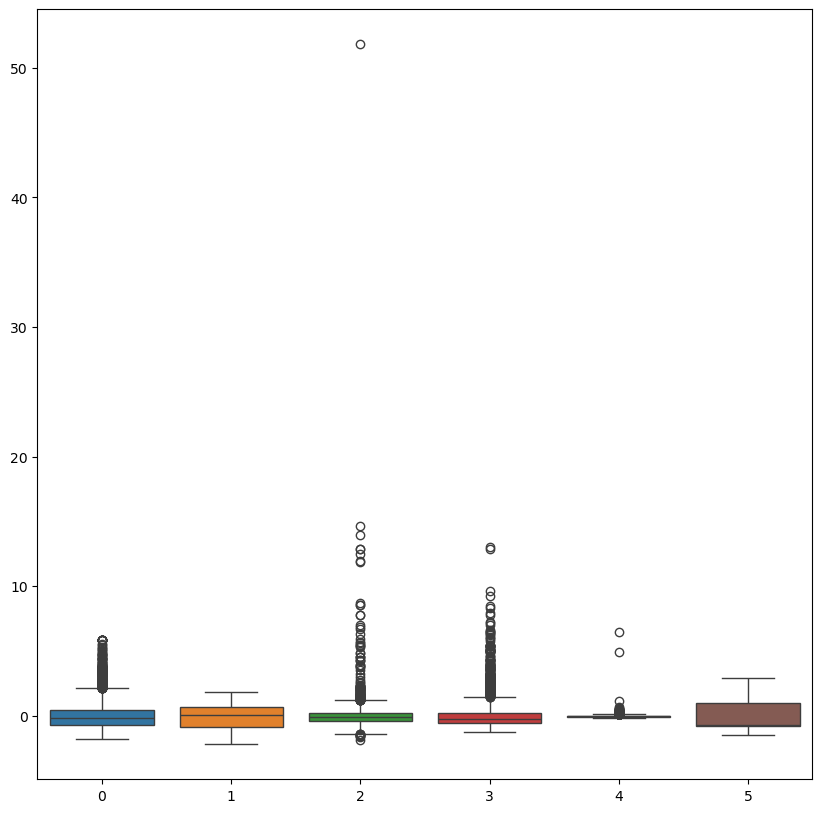

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.boxplot(data=X_test_norm, ax=ax)
# plt.savefig("boxplotTraindata.png")

### Model training

In [30]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train_norm, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
print(regression.coef_)

[ 0.83151851  0.2221226  -0.04574944  0.02435654 -0.04987447 -0.09353637]


In [32]:
print(regression.intercept_)

2.0692396089424143


### Model Prediction

In [33]:
reg_pred = regression.predict(X_test_norm)
reg_pred

array([1.04927477, 1.54143892, 2.24622242, ..., 1.88612132, 1.64142627,
       1.66931348], shape=(6192,))

In [34]:
# Claculate the error or residuals
residuals = y_test - reg_pred

In [35]:
residuals

20046   -0.572275
3024    -1.083439
15663    2.753788
20484   -0.542757
9814     0.730247
           ...   
17505    0.450923
13512   -0.645169
10842    0.297879
16559   -0.447426
5786     0.428687
Name: Price, Length: 6192, dtype: float64

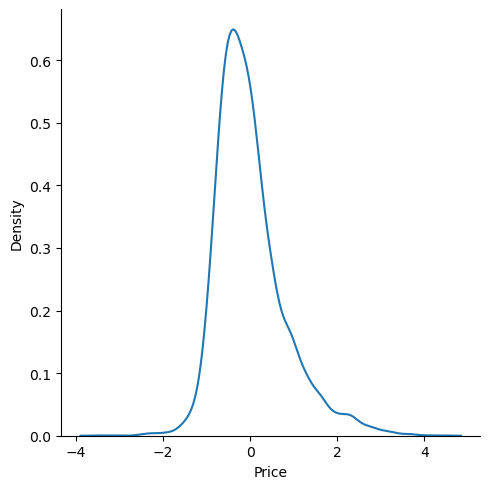

In [36]:
# distribution plot for the residuals
# distribution plot for the residuals
sns.displot(residuals, kind='kde')

### Model Performence

In [37]:
# lower error value - MSE and MAE
# higher value - r2 score and adjusted r2 score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Mean Absolute Error:", mean_absolute_error(y_test, reg_pred))
print("Mean Squared Error:", mean_squared_error(y_test, reg_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, reg_pred)))
print("R^2 Score:", r2_score(y_test, reg_pred))

Mean Absolute Error: 0.5919280736616849
Mean Squared Error: 0.6284038514263594
Root Mean Squared Error: 0.7927192765578237
R^2 Score: 0.5212307435899888


In [38]:
score = r2_score(y_test, reg_pred)

In [39]:
# Adjusted r2 score 
adj_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test_norm.shape[1]-1)
adj_r2

0.520766294836802

### Save the model -> pickel file

In [40]:
import pickle
pickle.dump(regression, open("house_price_model.pkl", "wb"))

In [41]:
# load the model and use it for prediction
model = pickle.load(open("house_price_model.pkl", "rb"))

In [42]:
arr = housing.data[0].reshape(1, -1)
new_arr = np.delete(arr, [3, 7], axis=1)
new_arr

array([[  8.3252    ,  41.        ,   6.98412698, 322.        ,
          2.55555556,  37.88      ]])

In [43]:
model.predict(new_arr)

array([21.95149667])

### Applying Regularization Technique: to avoide overfitting in the model

In [44]:
from sklearn.linear_model import Lasso, Ridge
lasso_regression = Lasso(alpha=0.1)
lasso_regression.fit(X_train_norm, y_train)

ridge_regression = Ridge(alpha=0.1)
ridge_regression.fit(X_train_norm, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [49]:
lasso_pred = lasso_regression.predict(X_test_norm)
lasso_pred

array([1.2205456 , 1.58340606, 2.10916044, ..., 1.83694644, 1.81729865,
       1.67200076], shape=(6192,))

In [50]:
ridge_pred = ridge_regression.predict(X_test_norm)
ridge_pred

array([1.0492821 , 1.54144301, 2.24621829, ..., 1.88612131, 1.6414275 ,
       1.66931508], shape=(6192,))

In [51]:
print("Mean Absolute Error:", mean_absolute_error(y_test, lasso_pred))
print("Mean Squared Error:", mean_squared_error(y_test, lasso_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R^2 Score:", r2_score(y_test, lasso_pred))

Mean Absolute Error: 0.6164943441720094
Mean Squared Error: 0.6648117801052066
Root Mean Squared Error: 0.8153599083258918
R^2 Score: 0.4934922170016566


In [52]:
print("Mean Absolute Error:", mean_absolute_error(y_test, ridge_pred))
print("Mean Squared Error:", mean_squared_error(y_test, ridge_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R^2 Score:", r2_score(y_test, ridge_pred))

Mean Absolute Error: 0.5919285049837635
Mean Squared Error: 0.628403901778809
Root Mean Squared Error: 0.7927193083171427
R^2 Score: 0.5212307052273899
